# Tech Challenge (FIAP) — Previsão de Alta/Baixa do IBOVESPA (Semi-pronto)



## 1) Carregar dados (CSV do Investing)


In [ ]:
import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True, parents=True)

# ====== Upload (Colab) ======
try:
    from google.colab import files
    uploaded = files.upload()
    CSV_PATH = next(iter(uploaded.keys()))
    print("Arquivo carregado:", CSV_PATH)
except Exception:
    CSV_PATH = None
    print("Upload não foi usado. Defina CSV_PATH manualmente.")

assert CSV_PATH is not None, "Defina CSV_PATH com o caminho do seu CSV."


Saving Dados Históricos - Ibovespa.csv to Dados Históricos - Ibovespa (1).csv
Arquivo carregado: Dados Históricos - Ibovespa (1).csv


## 2) Leitura robusta (PT/EN) + limpeza

Este bloco padroniza colunas e converte números/volume.

In [ ]:
import unicodedata

def strip_accents(s: str) -> str:
    return ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))

def parse_number_locale(x, locale='pt'):
    # Converte string numérica para float.
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in ('', '-', 'nan', 'NaN'):
        return np.nan
    s = s.replace('%','').replace(' ','')
    if locale == 'pt':
        s = s.replace('.','').replace(',','.')
    else:
        s = s.replace(',','')
    s = re.sub(r'[^0-9\.\-]', '', s)
    if s in ('', '-', '.'):
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

def parse_volume(x, locale='pt'):
    # Converte Volume com sufixos K/M/B (ex.: '1,2M', '350K').
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper().replace(' ','')
    if s in ('', '-', 'N/A', 'NAN'):
        return np.nan
    mult = 1.0
    if s.endswith('K'):
        mult = 1e3; s = s[:-1]
    elif s.endswith('M'):
        mult = 1e6; s = s[:-1]
    elif s.endswith('B'):
        mult = 1e9; s = s[:-1]
    return parse_number_locale(s, locale=locale) * mult

def guess_locale(df_raw: pd.DataFrame):
    for col in df_raw.columns:
        if df_raw[col].dtype == object:
            sample = df_raw[col].dropna().astype(str).head(50).tolist()
            if any(',' in v and '.' in v for v in sample):
                return 'pt'  # converte 1.234,56
    return 'en'

df_raw = pd.read_csv(CSV_PATH)
locale = guess_locale(df_raw)
print('Locale inferido:', locale)

# Mapeia colunas
cols_map = {}
for c in df_raw.columns:
    c2 = strip_accents(str(c)).strip().lower()
    c2 = re.sub(r'\s+',' ', c2)
    if c2 in ('data','date'):
        cols_map[c] = 'Date'
    elif c2 in ('ultimo','ult.','ultimo preco','ultimo preço','last','close','fechamento','preco de fechamento','preco'):
        cols_map[c] = 'Close'
    elif c2 in ('abertura','open'):
        cols_map[c] = 'Open'
    elif c2 in ('maxima','high'):
        cols_map[c] = 'High'
    elif c2 in ('minima','low'):
        cols_map[c] = 'Low'
    elif 'vol' in c2:
        cols_map[c] = 'Volume'
    elif 'var' in c2:
        cols_map[c] = 'VarPct'

df = df_raw.rename(columns=cols_map).copy()
assert 'Date' in df.columns and 'Close' in df.columns, f"CSV precisa ter Date e Close. Colunas: {df.columns.tolist()}"

df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
df = df.dropna(subset=['Date']).copy()

for c in ['Open','High','Low','Close']:
    if c in df.columns:
        df[c] = df[c].apply(lambda v: parse_number_locale(v, locale))

if 'Volume' in df.columns:
    df['Volume'] = df['Volume'].apply(lambda v: parse_volume(v, locale))

df = df.sort_values('Date').drop_duplicates(subset=['Date']).reset_index(drop=True)
df = df.set_index('Date')

display(df.head())
print('Período:', df.index.min().date(), '->', df.index.max().date(), '| linhas:', len(df))


Locale inferido: en


,Close,Open,High,Low,Volume,VarPct
Date,,,,,,
2020-01-02,118.573,115.652,118.573,115.649,516000000.0,"2,53%"
2020-01-03,117.707,118.564,118.792,117.341,683000000.0,"-0,73%"
2020-01-06,116.878,117.707,117.707,116.269,657000000.0,"-0,70%"
2020-01-07,116.662,116.872,117.076,115.965,485000000.0,"-0,18%"
2020-01-08,116.247,116.667,117.335,115.693,591000000.0,"-0,36%"


Período: 2020-01-02 -> 2026-01-09 | linhas: 1501


## 3) EDA rápida (série + retornos)

Relatorios

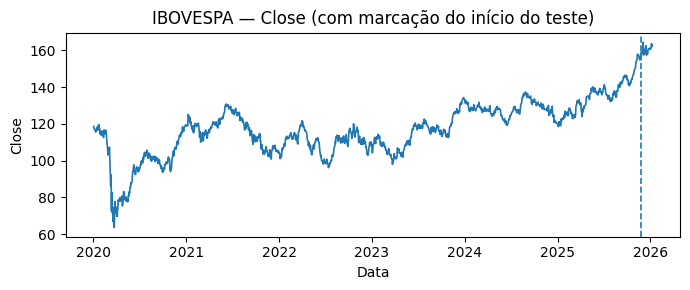

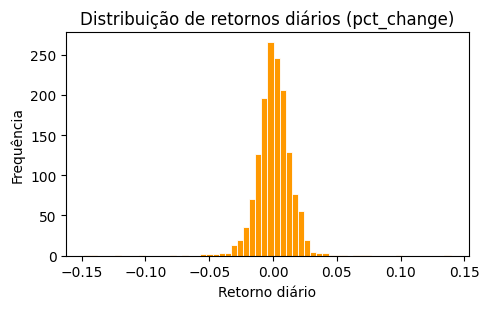

In [ ]:
# Série Close com marcação do início do teste
test_start_idx = max(len(df) - 30, 0)
test_start_date = df.index[test_start_idx] if len(df) >= 30 else None

plt.figure(figsize=(7, 3))
plt.plot(df.index, df['Close'], linewidth=1.2)
if test_start_date is not None:
    plt.axvline(test_start_date, linestyle='--', linewidth=1.2)
plt.title('IBOVESPA — Close (com marcação do início do teste)')
plt.xlabel('Data'); plt.ylabel('Close')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_close_split.png', dpi=130)
plt.show()

# Retorno diário
df['ret_1d'] = df['Close'].pct_change()

plt.figure(figsize=(5, 3.2))
plt.hist(
    df['ret_1d'].dropna(),
    bins=60,
    color='#ff9900ff',
    edgecolor='white',
    linewidth=0.6
)
plt.title('Distribuição de retornos diários (pct_change)')
plt.xlabel('Retorno diário'); plt.ylabel('Frequência')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_return_hist.png', dpi=130)
plt.show()

## 4) Feature engineering (sem vazamento)

Cria janelas, lags e indicadores (RSI/MACD/Bollinger).

In [ ]:
def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.ewm(alpha=1/period, adjust=False).mean()
    roll_down = down.ewm(alpha=1/period, adjust=False).mean()
    rs = roll_up / (roll_down + 1e-12)
    return 100 - (100 / (1 + rs))

# Candles
if all(c in df.columns for c in ['Open','High','Low','Close']):
    df['candle_body'] = (df['Close'] - df['Open']) / df['Open']
    df['candle_range'] = (df['High'] - df['Low']) / df['Close']
    df['gap_open'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)

# Médias móveis
for w in [5, 10, 20, 50]:
    df[f'sma_{w}'] = df['Close'].rolling(w).mean()
    df[f'close_sma_{w}'] = df['Close'] / df[f'sma_{w}'] - 1
    df[f'vol_{w}'] = df['ret_1d'].rolling(w).std()

# ✅ Estatísticas de retorno (sem vazamento):
for w in [3, 5, 10]:
    df[f'ret_mean_{w}'] = df['ret_1d'].rolling(w).mean()
    df[f'ret_sum_{w}']  = df['ret_1d'].rolling(w).sum()

# EMA + MACD
df['ema_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['ema_26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['macd'] = df['ema_12'] - df['ema_26']
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist'] = df['macd'] - df['macd_signal']

# Bollinger (20)
df['bb_mid'] = df['Close'].rolling(20).mean()
df['bb_std'] = df['Close'].rolling(20).std()
df['bb_upper'] = df['bb_mid'] + 2*df['bb_std']
df['bb_lower'] = df['bb_mid'] - 2*df['bb_std']
df['bb_pos'] = (df['Close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'] + 1e-12)

# RSI
df['rsi_14'] = rsi(df['Close'], 14)

# Lags de retorno (memória do passado)
for lag in range(1, 11):
    df[f'ret_lag{lag}'] = df['ret_1d'].shift(lag)

# Dia da semana
df['dow'] = df.index.dayofweek

# Target: 1 se amanhã fechar acima de hoje (último dia vira NaN, não vira 0)
future_close = df['Close'].shift(-1)
df['target'] = np.where(future_close.isna(), np.nan, (future_close > df['Close']).astype(int))

# Remove última linha (não tem amanhã)
df = df.dropna(subset=['target']).copy()
df['target'] = df['target'].astype(int)

display(df.tail())

,Close,Open,High,Low,Volume,VarPct,ret_1d,target,candle_body,candle_range,...,ret_lag2,ret_lag3,ret_lag4,ret_lag5,ret_lag6,ret_lag7,ret_lag8,ret_lag9,ret_lag10,dow
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-30,161.125,160.491,162.075,160.491,5.870000e+11,"0,40%",0.003957,0,0.003950,0.009831,...,0.002748,0.014632,-0.002089,0.003483,0.003788,-0.007889,-0.024027,0.010674,0.009906,1
2026-01-02,160.539,161.124,161.957,160.059,7.460000e+11,"-0,36%",-0.003637,1,-0.003631,0.011823,...,-0.002530,0.002748,0.014632,-0.002089,0.003483,0.003788,-0.007889,-0.024027,0.010674,4
2026-01-05,161.870,160.542,162.166,160.215,7.990000e+11,"0,83%",0.008291,1,0.008272,0.012053,...,0.003957,-0.002530,0.002748,0.014632,-0.002089,0.003483,0.003788,-0.007889,-0.024027,0
2026-01-06,163.664,161.870,164.135,161.870,8.410000e+11,"1,11%",0.011083,0,0.011083,0.013839,...,-0.003637,0.003957,-0.002530,0.002748,0.014632,-0.002089,0.003483,0.003788,-0.007889,1
2026-01-07,161.975,163.661,163.661,161.746,8.850000e+11,"-1,03%",-0.010320,1,-0.010302,0.011823,...,0.008291,-0.003637,0.003957,-0.002530,0.002748,0.014632,-0.002089,0.003483,0.003788,2


## 5) Dataset final (X/y) + balanceamento

Linhas após dropna: 1449
Features: 28


,count
target,
0,695
1,754


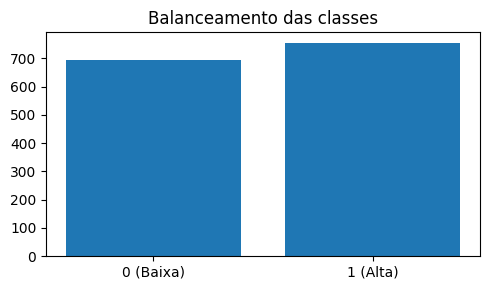

In [ ]:
feature_cols = []

# Candles
for c in ['candle_body', 'candle_range', 'gap_open']:
    if c in df.columns:
        feature_cols.append(c)

# Médias / volatilidade / indicadores
feature_cols += [c for c in df.columns if c.startswith('close_sma_')]
feature_cols += [c for c in df.columns if c.startswith('vol_')]
feature_cols += ['macd', 'macd_signal', 'macd_hist', 'bb_pos', 'rsi_14']

# Retorno do dia
if 'ret_1d' in df.columns:
    feature_cols += ['ret_1d']

# Lags de retorno
feature_cols += [c for c in df.columns if c.startswith('ret_lag')]

# Volume
if 'Volume' in df.columns:
    df['vol_log'] = np.log(df['Volume'].replace(0, np.nan))
    feature_cols += ['vol_log']

# Remove duplicadas e mantém só colunas existentes
feature_cols = sorted(list(dict.fromkeys([c for c in feature_cols if c in df.columns])))

# Dataset final
data = df[feature_cols + ['target', 'dow']].dropna().copy()
print('Linhas após dropna:', len(data))
print('Features:', len(feature_cols))

X = data[feature_cols].copy()
X = pd.concat([X, pd.get_dummies(data['dow'], prefix='dow', drop_first=True)], axis=1)

y = data['target'].astype(int)

counts = y.value_counts().sort_index()
display(counts)

plt.figure(figsize=(5,3))
plt.bar(['0 (Baixa)','1 (Alta)'], [counts.get(0,0), counts.get(1,0)])
plt.title('Balanceamento das classes')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig3_class_balance.png', dpi=160)
plt.show()

## 6) Split temporal (últimos 30 dias)

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

TEST_DAYS = 30

X_train, X_test = X.iloc[:-TEST_DAYS].copy(), X.iloc[-TEST_DAYS:].copy()
y_train, y_test = y.iloc[:-TEST_DAYS].copy(), y.iloc[-TEST_DAYS:].copy()

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Teste:', X_test.index.min().date(), '->', X_test.index.max().date())


Train: (1419, 32) | Test: (30, 32)
Teste: 2025-11-21 -> 2026-01-07


In [ ]:
from datetime import datetime

TEST_DAYS = 30

# Split temporal
X_train, X_test = X.iloc[:-TEST_DAYS].copy(), X.iloc[-TEST_DAYS:].copy()
y_train, y_test = y.iloc[:-TEST_DAYS].copy(), y.iloc[-TEST_DAYS:].copy()

# Helpers de formatação
def fmt_date(d):
    return pd.to_datetime(d).strftime("%d/%m/%Y")

train_start, train_end = X_train.index.min(), X_train.index.max()
test_start,  test_end  = X_test.index.min(),  X_test.index.max()

n_train, p = X_train.shape
n_test, _  = X_test.shape

print("=" * 60)
print("6) Split temporal (últimos 30 pregões = teste)")
print("-" * 60)
print(f"Treino: {n_train} linhas | {p} features | {fmt_date(train_start)} → {fmt_date(train_end)}")
print(f"Teste : {n_test} linhas  | {p} features | {fmt_date(test_start)} → {fmt_date(test_end)}")
print("=" * 60)

train_rate = float(y_train.mean())
test_rate  = float(y_test.mean())
print(f"Taxa de 'Alta' (1) no treino: {train_rate:.1%} | no teste: {test_rate:.1%}")


6) Split temporal (últimos 30 pregões = teste)
------------------------------------------------------------
Treino: 1419 linhas | 32 features | 16/03/2020 → 19/11/2025
Teste : 30 linhas  | 32 features | 21/11/2025 → 07/01/2026
Taxa de 'Alta' (1) no treino: 51.7% | no teste: 66.7%


## 7) Baselines + Validação Walk-forward (TimeSeriesSplit)

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Baseline
majority = int(y_train.value_counts().idxmax())
y_pred_base = np.full_like(y_test.values, majority)
acc_base = accuracy_score(y_test, y_pred_base)
print('Baseline (classe majoritária):', majority, '| Acurácia teste:', round(acc_base, 4))

# Outros Modelos, analisando apenas acuracidade
model_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', C=0.5))
])

model_hgb = HistGradientBoostingClassifier(
    max_depth=3,
    learning_rate=0.05,
    max_iter=600,
    random_state=42
)

models = {'LogReg': model_lr, 'HistGB': model_hgb}

def walk_forward_cv_balacc(model, X_tr, y_tr, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = []
    for tr_idx, val_idx in tscv.split(X_tr):
        X_tr_f, X_val_f = X_tr.iloc[tr_idx], X_tr.iloc[val_idx]
        y_tr_f, y_val_f = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]
        model.fit(X_tr_f, y_tr_f)
        pred = model.predict(X_val_f)
        scores.append(balanced_accuracy_score(y_val_f, pred))
    return float(np.mean(scores)), [float(s) for s in scores]

cv_results = {}
for name, m in models.items():
    mean_balacc, folds = walk_forward_cv_balacc(m, X_train, y_train, n_splits=5)
    cv_results[name] = {'mean_balacc': mean_balacc, 'fold_balacc': folds}
    print(f"{name} | CV mean bal_acc={mean_balacc:.4f} | folds={[round(s,3) for s in folds]}")

Baseline (classe majoritária): 1 | Acurácia teste: 0.6667
LogReg | CV mean bal_acc=0.5075 | folds=[0.529, 0.507, 0.517, 0.49, 0.494]
HistGB | CV mean bal_acc=0.5013 | folds=[0.543, 0.434, 0.508, 0.504, 0.518]


## 8) Treinar o melhor modelo e avaliar no teste (30 dias)

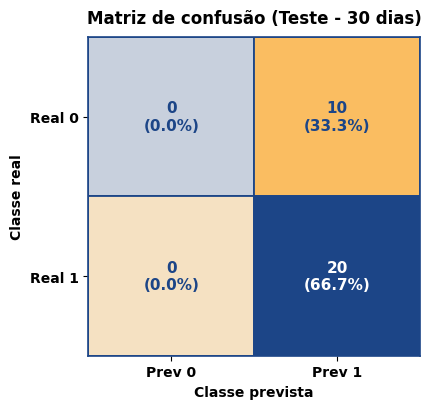

In [ ]:
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

cm = confusion_matrix(y_test, y_pred)

COL_ORANGE = "#ff9900ff"
COL_BLUE   = "#1c4587ff"
COL_BG     = "#f3f3f3ff"

bg = mcolors.to_rgba(COL_BG)
blue = mcolors.to_rgba(COL_BLUE)
orange = mcolors.to_rgba(COL_ORANGE)

def blend(c1, c2, t):
    """Mistura c1->c2 com intensidade t (0..1)."""
    t = max(0.0, min(1.0, float(t)))
    return tuple((1 - t) * c1[k] + t * c2[k] for k in range(4))

def luminance(rgba):
    r, g, b, _ = rgba
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

n = cm.shape[0]
total = cm.sum() if cm.sum() != 0 else 1
mx = cm.max() if cm.max() != 0 else 1

fig, ax = plt.subplots(figsize=(4.4, 4.2))
ax.set_facecolor(COL_BG)

for i in range(n):
    for j in range(n):
        v = cm[i, j]
        t = v / mx  # intensidade relativa
        base = blue if i == j else orange

        cell_color = blend(bg, base, 0.20 + 0.80 * t)

        ax.add_patch(
            Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                facecolor=cell_color,
                edgecolor=COL_BLUE,
                linewidth=1.3
            )
        )

        pct = 100 * (v / total)
        txt = f"{v}\n({pct:.1f}%)"

        txt_color = "white" if luminance(cell_color) < 0.55 else COL_BLUE

        ax.text(j, i, txt, ha="center", va="center",
                fontsize=11, fontweight="bold", color=txt_color)

# Eixos
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)  # mantém a linha 0 no topo (visual padrão)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([f"Prev {k}" for k in range(n)], fontweight="bold")
ax.set_yticklabels([f"Real {k}" for k in range(n)], fontweight="bold")

ax.set_title("Matriz de confusão (Teste - 30 dias)", fontweight="bold", pad=10)
ax.set_xlabel("Classe prevista", fontweight="bold")
ax.set_ylabel("Classe real", fontweight="bold")

# Borda mais “clean”
for spine in ax.spines.values():
    spine.set_color(COL_BLUE)
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.savefig(OUT_DIR / "fig4_confusion.png", dpi=160, facecolor="white")
plt.show()

## 9) Importância de features (para justificar o modelo no texto)

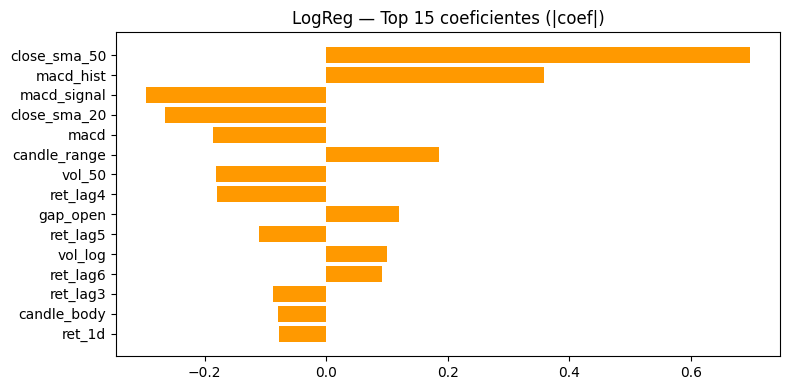

In [ ]:
fi_path = OUT_DIR / "fig5_feature_importance.png"
BAR_COLOR = "#ff9900ff"

if best_name == "LogReg":
    coef = best_model.named_steps["clf"].coef_[0]
    imp = pd.Series(coef, index=X_train.columns)
    imp = imp.reindex(imp.abs().sort_values(ascending=False).index).head(15)

    plt.figure(figsize=(8, 4))
    plt.barh(imp.index[::-1], imp.values[::-1], color=BAR_COLOR)
    plt.title("LogReg — Top 15 coeficientes (|coef|)")
    plt.tight_layout()
    plt.savefig(fi_path, dpi=160)
    plt.show()

elif hasattr(best_model, "feature_importances_"):
    imp = (
        pd.Series(best_model.feature_importances_, index=X_train.columns)
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(8, 4))
    plt.barh(imp.index[::-1], imp.values[::-1], color=BAR_COLOR)
    plt.title("HistGB — Top 15 importâncias")
    plt.tight_layout()
    plt.savefig(fi_path, dpi=160)
    plt.show()

else:
    print("Modelo não expõe importância diretamente.")

## 10) Real vs Previsto no tempo (últimos 30 dias)

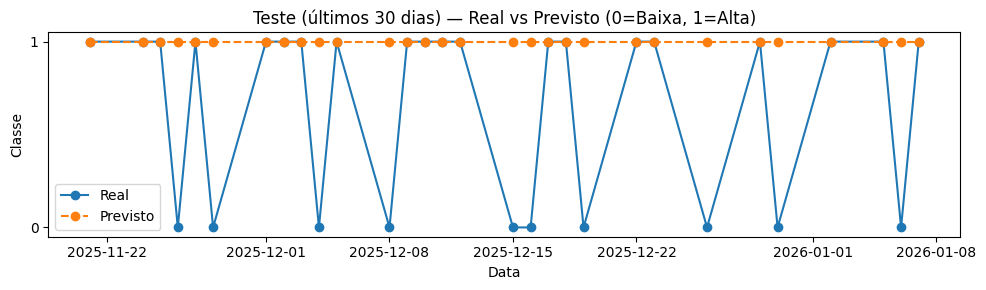

In [ ]:
plt.figure(figsize=(10,3))
plt.plot(pred_df.index, pred_df['y_true'], marker='o', linestyle='-', label='Real')
plt.plot(pred_df.index, pred_df['y_pred'], marker='o', linestyle='--', label='Previsto')
plt.title('Teste (últimos 30 dias) — Real vs Previsto (0=Baixa, 1=Alta)')
plt.xlabel('Data'); plt.ylabel('Classe')
plt.yticks([0,1], ['0','1'])
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig6_test_timeline.png', dpi=160)
plt.show()


In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    confusion_matrix, classification_report
)

#1) Baseline
majority = int(y_train.value_counts().idxmax())
y_pred_base = np.full_like(y_test.values, majority)
acc_base = accuracy_score(y_test, y_pred_base)
balacc_base = balanced_accuracy_score(y_test, y_pred_base)

print("BASELINE (classe majoritária):", majority)
print("Acurácia teste:", round(acc_base, 4))
print("Balanced acc teste:", round(balacc_base, 4))
print()

# 2) Modelos
models = {

    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5, random_state=42))
    ]),

    "HistGB": HistGradientBoostingClassifier(
        max_depth=3, learning_rate=0.05, max_iter=600, random_state=42
    ),


    "RandomForest": RandomForestClassifier(
        n_estimators=800,
        max_depth=8,
        min_samples_leaf=8,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),


    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=1200,
        max_depth=10,
        min_samples_leaf=6,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
}

def walk_forward_cv(model, X_tr, y_tr, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    accs, balaccs = [], []

    for tr_idx, val_idx in tscv.split(X_tr):
        X_tr_f, X_val_f = X_tr.iloc[tr_idx], X_tr.iloc[val_idx]
        y_tr_f, y_val_f = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]

        m = clone(model)
        m.fit(X_tr_f, y_tr_f)
        pred = m.predict(X_val_f)

        accs.append(accuracy_score(y_val_f, pred))
        balaccs.append(balanced_accuracy_score(y_val_f, pred))

    return float(np.mean(accs)), float(np.mean(balaccs))

cv_rows = []
for name, model in models.items():
    mean_acc, mean_balacc = walk_forward_cv(model, X_train, y_train, n_splits=5)
    cv_rows.append({
        "Modelo": name,
        "CV Acc (mean)": round(mean_acc, 4),
        "CV BalAcc (mean)": round(mean_balacc, 4)
    })

cv_df = pd.DataFrame(cv_rows).sort_values("CV Acc (mean)", ascending=False)
display(cv_df)

test_rows = []
for name, model in models.items():
    m = clone(model)
    m.fit(X_train, y_train)
    pred = m.predict(X_test)

    acc = accuracy_score(y_test, pred)
    balacc = balanced_accuracy_score(y_test, pred)
    pos_rate = float(np.mean(pred))
    cm = confusion_matrix(y_test, pred)

    test_rows.append({
        "Modelo": name,
        "Teste Acc": round(float(acc), 4),
        "Teste BalAcc": round(float(balacc), 4),
        "Taxa prevista de Alta": round(pos_rate, 4),
        "CM [[TN,FP],[FN,TP]]": cm.tolist()
    })

test_df = pd.DataFrame(test_rows).sort_values("Teste Acc", ascending=False)
display(test_df)

#Relatorio
best_test_name = test_df.iloc[0]["Modelo"]
best_model = clone(models[best_test_name]).fit(X_train, y_train)
best_pred = best_model.predict(X_test)

print("Melhor no TESTE (por acurácia):", best_test_name)
print("Acurácia:", round(accuracy_score(y_test, best_pred), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, best_pred), 4))
print()
print(classification_report(y_test, best_pred, digits=4))


BASELINE (classe majoritária): 1
Acurácia teste: 0.6667
Balanced acc teste: 0.5



,Modelo,CV Acc (mean),CV BalAcc (mean)
3,ExtraTrees,0.5212,0.5217
2,RandomForest,0.5169,0.5172
0,LogReg,0.5127,0.5075
1,HistGB,0.5034,0.5013


,Modelo,Teste Acc,Teste BalAcc,Taxa prevista de Alta,"CM [[TN,FP],[FN,TP]]"
1,HistGB,0.6000,0.600,0.5333,"[[6, 4], [8, 12]]"
0,LogReg,0.4333,0.525,0.2333,"[[8, 2], [15, 5]]"
2,RandomForest,0.4333,0.500,0.3000,"[[7, 3], [14, 6]]"
3,ExtraTrees,0.4333,0.525,0.2333,"[[8, 2], [15, 5]]"


Melhor no TESTE (por acurácia): HistGB
Acurácia: 0.6
Balanced accuracy: 0.6

              precision    recall  f1-score   support

           0     0.4286    0.6000    0.5000        10
           1     0.7500    0.6000    0.6667        20

    accuracy                         0.6000        30
   macro avg     0.5893    0.6000    0.5833        30
weighted avg     0.6429    0.6000    0.6111        30



NameError: name 'OUT_DIR' is not defined

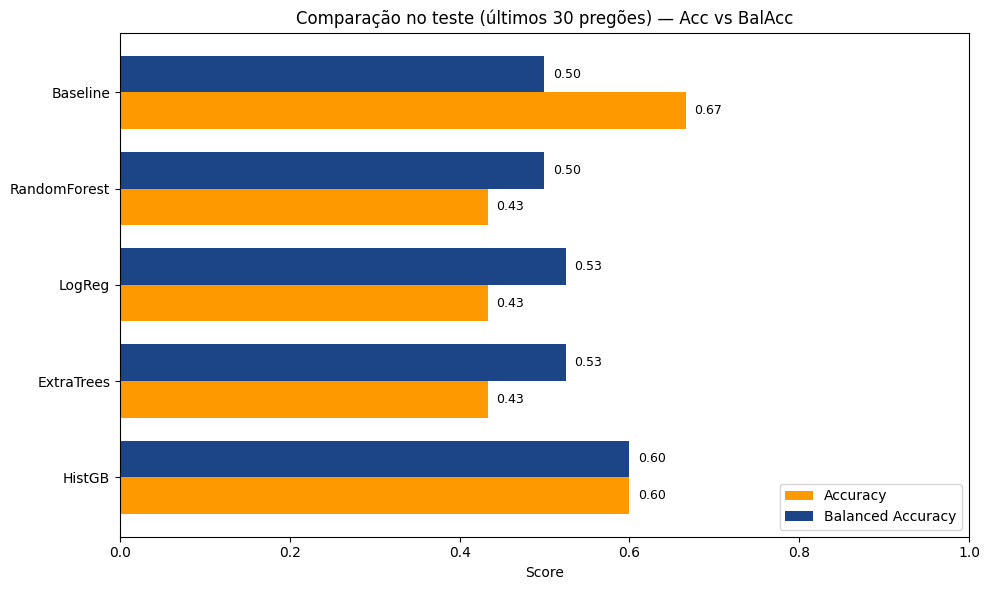

In [2]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["Baseline", "LogReg", "RandomForest", "ExtraTrees", "HistGB"]
acc    = [0.6667,     0.4333,   0.4333,       0.4333,     0.6000]
balacc = [0.5000,     0.5250,   0.5000,       0.5250,     0.6000]

# Ordena por BalAcc (melhor em cima)
order = np.argsort(balacc)[::-1]
labels = [labels[i] for i in order]
acc    = [acc[i]    for i in order]
balacc = [balacc[i] for i in order]

y = np.arange(len(labels))
h = 0.38

plt.figure(figsize=(10, 6))
plt.barh(y - h/2, acc,    height=h, label="Accuracy",          color="#ff9900ff")
plt.barh(y + h/2, balacc, height=h, label="Balanced Accuracy", color="#1c4587ff")

plt.yticks(y, labels)
plt.xlim(0, 1)
plt.xlabel("Score")
plt.title("Comparação no teste (últimos 30 pregões) — Acc vs BalAcc")

# Rótulos nas barras
for i, v in enumerate(acc):
    plt.text(v + 0.01, i - h/2, f"{v:.2f}", va="center", fontsize=9)
for i, v in enumerate(balacc):
    plt.text(v + 0.01, i + h/2, f"{v:.2f}", va="center", fontsize=9)

plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_models_acc_vs_balacc_h.png", dpi=160)  # sem mexer no fundo
plt.show()
